# PCA — Dimensionality Reduction

Each 28×28 image lives in a **784-dimensional** pixel space, but a few visually distinct classes occupy a much thinner slice of it. This notebook uses **Principal Component Analysis** to find that slice: an orthogonal basis ordered by how much variance each axis explains.

We run the **same analysis on two datasets**, using the whole of each:

- **Part 1 — MNIST** digits `0 / 1 / 2` ([`utils/mnist_data.py`](../utils/mnist_data.py))
- **Part 2 — Quick, Draw!** sketches `cat / apple / car` ([`utils/data_import.py`](../utils/data_import.py))

Both loaders share the exact same contract — a flat, `[0, 1]`-scaled `(n, 784)` matrix `X` with 0 = background, 1 = ink — so the helpers in [`utils/pca/dim_reduction.py`](../utils/pca/dim_reduction.py) (PCA implemented from scratch: mean-centering, a covariance matrix, and an eigendecomposition, no `sklearn.decomposition.PCA`) run unchanged on either. For each dataset we:

1. plot the scree / cumulative explained-variance curve,
2. report how many components reach **90%** and **95%** of the variance, and
3. scatter the first 2 (and 3) principal components, colored by class.

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the kernel starts at the repo root, in src/, or in src/pca/.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

In [2]:
import numpy as np

from utils.mnist_data import load_digits, DIGITS
from utils.data_import import load_sketches, CLASSES
from utils.pca.dim_reduction import (
    fit_pca, project,
    plot_spectrum, plot_spectrum_comparison, plot_projection,
    plot_pc1_vs_mean, plot_eigenimages, plot_component_heatmaps,
)

# Per-class sample cap. MNIST's classes are all smaller than this, so every
# training image is used; Quick, Draw!'s much larger categories are capped to it.
PER_CLASS = 10000
DIGITS, CLASSES

((0, 1, 2), ['cat', 'apple', 'car'])

# Part 1 — MNIST digits (0 / 1 / 2)

## Load the data

MNIST's training split contains 5 923 `0`s, 6 742 `1`s and 5 958 `2`s. The
loader caps each class at `PER_CLASS = 10 000` samples; since every class holds
fewer than that, all **18 623** training images are used. The result is a flat,
`[0, 1]`-scaled design matrix `X` of shape `(18623, 784)` — one image per row —
and its integer label vector `y`.

In [3]:
X, y = load_digits(per_class=PER_CLASS)
print(f"X {X.shape} {X.dtype} range [{X.min():.2f}, {X.max():.2f}]")
print(f"y {y.shape} classes {sorted(set(y.tolist()))}")

I0000 00:00:1784154429.548398    2335 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784154429.632944    2335 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784154431.400252    2335 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X (18623, 784) float32 range [0.00, 1.00]
y (18623,) classes [0, 1, 2]


## Fit PCA and inspect the spectrum

Fitting PCA with `n_components=None` keeps the full basis, so we can look at the whole variance spectrum before deciding how many components to keep.

In [4]:
pca = fit_pca(X)
print(f"fitted PCA with {pca.n_components_} components")
print(f"top-5 explained-variance ratios: {np.round(pca.explained_variance_ratio_[:5], 4)}")

fitted PCA with 784 components
top-5 explained-variance ratios: [0.2181 0.0915 0.0656 0.0568 0.0412]


### Inspecting what `fit_pca` computed

`fit_pca` performs the four PCA steps internally (mean-center → covariance →
eigendecomposition → sort by eigenvalue) and the returned `PCA` object **stores
their results**: `mean_`, `components_` (the sorted eigenvectors, one per row)
and `explained_variance_` (their eigenvalues). The cell below does not redo any
of that work — it simply reads those attributes off the fitted `pca` to reveal
the decomposition, and calls `pca.transform` to project one image.

The single exception is the covariance matrix: `fit_pca` uses it as an
intermediate but does not keep it (it would be a large 784×784 array), so it is
recomputed here purely to display its shape.

In [5]:
# All values below are read straight off the fitted `pca` object (except cov).

# Step 1: the mean fit_pca subtracted -- pca.mean_ is the per-pixel mean image.
print(f"1. mean_         shape={pca.mean_.shape} dtype={pca.mean_.dtype}")
print(pca.mean_[:10])

Xc = X - pca.mean_
print(f"\n   X centered    shape={Xc.shape}  mean~0: {Xc.mean():.2e}")

# Step 2: covariance matrix -- the one intermediate fit_pca does not store,
# recomputed here just to show it.
cov = (Xc.T @ Xc) / (X.shape[0] - 1)
print(f"\n2. covariance    shape={cov.shape} dtype={cov.dtype}")
print(cov[:3, :3])

# Step 3: eigendecomposition results, kept by fit_pca -- pca.components_ rows are
# the eigenvectors (principal axes), pca.explained_variance_ their eigenvalues.
print(f"\n3. components_   shape={pca.components_.shape}  (eigenvectors, one per row)")
print(pca.components_[0, :10])
print(f"\n   explained_variance_ (eigenvalues), top 5: {pca.explained_variance_[:5]}")

# Step 4: fit_pca returns them already sorted descending -- each eigenvalue >= the next.
print(f"\n4. sorted descending: {np.all(np.diff(pca.explained_variance_) <= 0)}")

# Step 5: project one image with pca.transform (centered image dotted with the axes).
one_image_coords = pca.transform(X[:1])
print(f"\n5. transform(X[:1]) -> shape={one_image_coords.shape}")
print(one_image_coords[0, :5])

1. mean_         shape=(784,) dtype=float64
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

   X centered    shape=(18623, 784)  mean~0: -9.55e-19

2. covariance    shape=(784, 784) dtype=float64
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

3. components_   shape=(784, 784)  (eigenvectors, one per row)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

   explained_variance_ (eigenvalues), top 5: [11.56687101  4.85199997  3.47919704  3.01206877  2.18622888]

4. sorted descending: True

5. transform(X[:1]) -> shape=(1, 784)
[-1.37731539 -1.61573988 -0.91983406 -1.09636912  1.10810812]


### Scree & cumulative explained variance

Left: the **scree plot** — variance explained by each component (they fall off fast). Right: the **cumulative** curve, with the 90% and 95% variance levels marked.

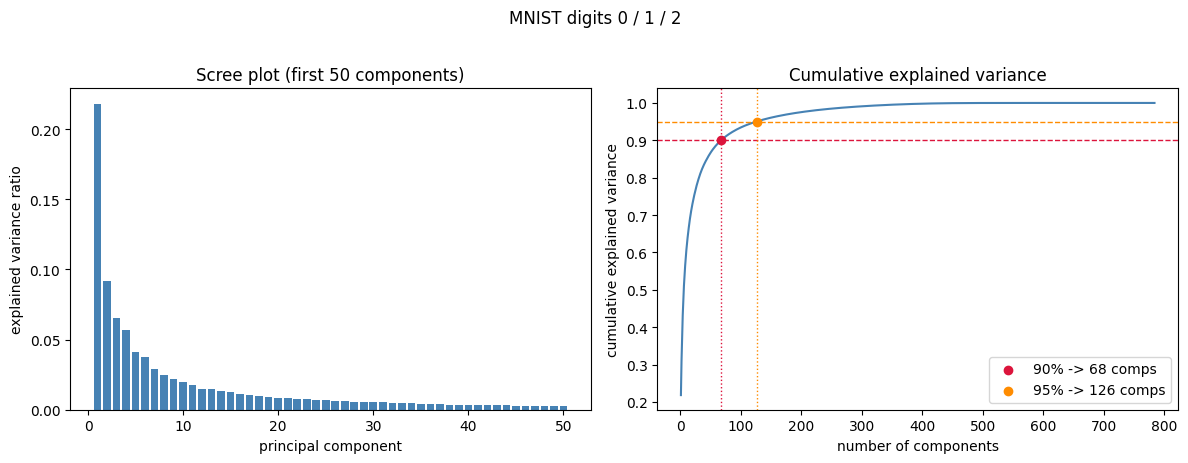

components for 90% variance: 68
components for 95% variance: 126


In [6]:
ks = plot_spectrum(pca, suptitle="MNIST digits 0 / 1 / 2")
print(f"components for 90% variance: {ks[0.90]}")
print(f"components for 95% variance: {ks[0.95]}")

So roughly **68 components** (out of 784) already capture 90% of the variance, and **126** capture 95% — an ~6-12x reduction in dimensionality with little information lost. The first few components dominate (PC1 alone ≈ 22%), which is exactly what makes the digits separable in a low-dimensional view below.

### Does the choice of mean matter? Per-feature vs. global centering

Step 1 of `fit_pca` subtracts a mean, and there are two candidates for it:

- **Per-feature mean** — `X.mean(axis=0)`, one value per pixel (the *mean image*).
  This is standard PCA: subtracting it makes the axes describe variation
  *around* the mean image.
- **Global mean** — `X.mean()`, a single scalar subtracted from every pixel.
  This only shifts the data by a constant, so the mean image is *left in*, and
  PCA spends its first component largely re-describing it.

`fit_pca(X, center="feature" | "global")` selects between them. Below we fit the
same data both ways and overlay their spectra.

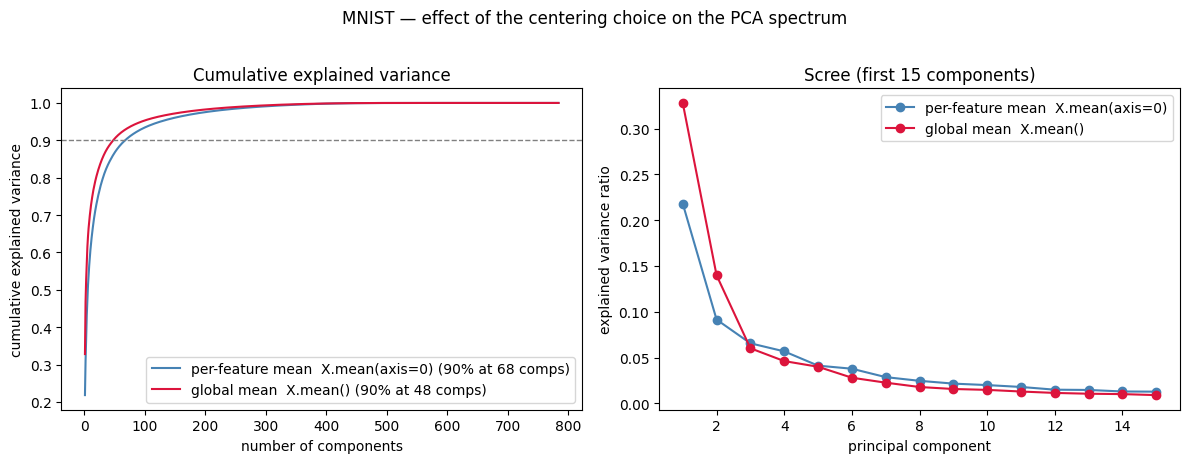

per-feature mean  X.mean(axis=0)    PC1 =  21.8% of variance   90% at 68 components
global mean  X.mean()               PC1 =  32.8% of variance   90% at 48 components


In [7]:
# Same data, two choices of mean to subtract (via fit_pca's `center` argument).
pca_feature = fit_pca(X, center="feature")  # per-feature mean, X.mean(axis=0)
pca_global = fit_pca(X, center="global")    # single global mean, X.mean()

summary = plot_spectrum_comparison(
    [pca_feature, pca_global],
    ["per-feature mean  X.mean(axis=0)", "global mean  X.mean()"],
    suptitle="MNIST — effect of the centering choice on the PCA spectrum",
)
for label, pc1, k90 in summary:
    print(f"{label:34}  PC1 = {pc1:6.1%} of variance   90% at {k90} components")

**Why "fewer components for 90%" is a trap, not a win.** Global centering reaches
90% variance in fewer components (48 vs 68), which *looks* more efficient — but it
isn't. Global centering subtracts only a single scalar, so the **mean image** (the
"average digit" present in *every* sample) is left in the data. PCA sees that
shared shape as a huge direction of variance and spends **PC1 re-encoding it**
(21.8% → 32.8%). That first component carries no information for telling a `0`
from a `2` — it just describes what all digits have in common. So 90% is reached
sooner only because one whole component was *wasted* on the common background, and
because the total variance it is measured against is itself inflated by that mean
image. Per-feature centering subtracts the mean image for free (it is stored
separately in `mean_`), so **every** component is left to describe the actual
variation *between* digits.

**Why the effect is strong here specifically.** Global centering effectively adds
to the covariance a term proportional to how *bold* the dataset's mean image is
(how far it sits from a flat, uniform image). MNIST digits are centered and
similarly sized, so their mean image is a sharp, high-contrast blob — a large term
— and PC1 is heavily distorted. Part 2 runs the same comparison on Quick, Draw!,
whose scattered sketches have a faint, diffuse mean image, and there the effect
nearly vanishes: **how much the centering choice matters depends on how structured
the dataset's mean image is.**

**Per-feature centering is therefore the correct default**, and every other
analysis in this notebook uses it.

### Seeing the components as images

The principal components are length-784 vectors, so each one reshapes back to a
28×28 image. Three views make the decomposition concrete — and turn the
centering argument above from words into pictures:

1. **PC1 vs. the mean image** — direct proof that global centering "wastes" PC1.
2. **Eigen-digits** — the mean image and leading components as grayscale images.
3. **± heatmaps** — the same components coloured by which pixels they add/remove.

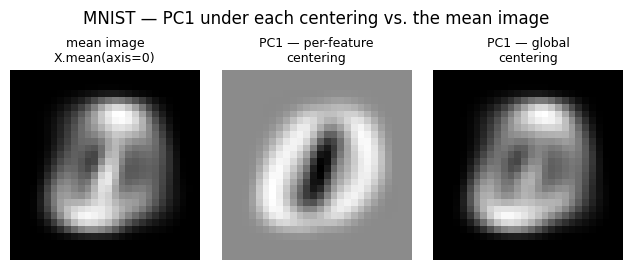

In [8]:
# 1. PC1 under each centering, next to the mean image (fits both centerings internally).
plot_pc1_vs_mean(X, suptitle="MNIST — PC1 under each centering vs. the mean image")

The resemblance is the whole point: **PC1 under global centering (right) looks
like the mean image (left)** — it is spending the top component re-drawing the
average digit. PC1 under per-feature centering (middle) looks nothing like the
mean; it is a genuine contrast pattern (ink added in some regions, removed in
others) that actually distinguishes digits.

Below, the mean image and leading components are shown as grayscale "eigen-digits"
and then as ± heatmaps — both using the correct per-feature centering.

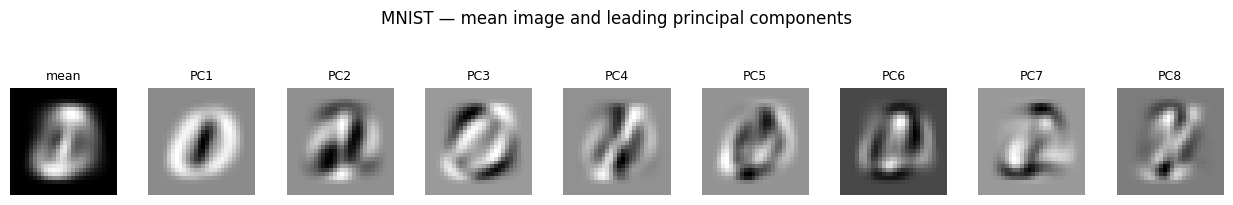

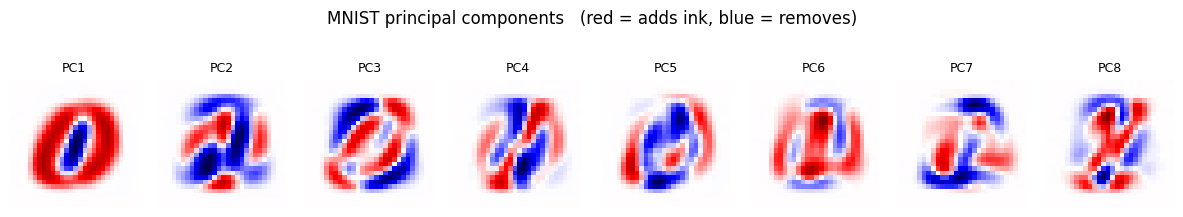

In [9]:
# 2. Mean image + top-8 components as grayscale "eigen-digits".
plot_eigenimages(pca, n=8, suptitle="MNIST — mean image and leading principal components")

# 3. The same components as +/- heatmaps (red adds ink, blue removes it).
plot_component_heatmaps(pca, n=8, suptitle="MNIST principal components")

Each digit is reconstructed as **the mean image plus a weighted sum of these
components** — that is exactly what the compression and generation notebooks do.
The leading components capture broad, low-frequency structure (overall stroke
mass, slant, the round-vs-straight contrast that separates `0`/`1`/`2`); later
ones add progressively finer detail. In the heatmaps, each axis visibly *moves
ink* from the blue regions to the red regions as its coordinate increases.

## Visualize the leading principal components

Projecting each image onto its top principal components collapses 784 pixels to
a handful of coordinates. We color each point by its true digit — which PCA
never saw — to see how well it separates the classes in 2D, then add PC3 for a
little more room where classes overlap.

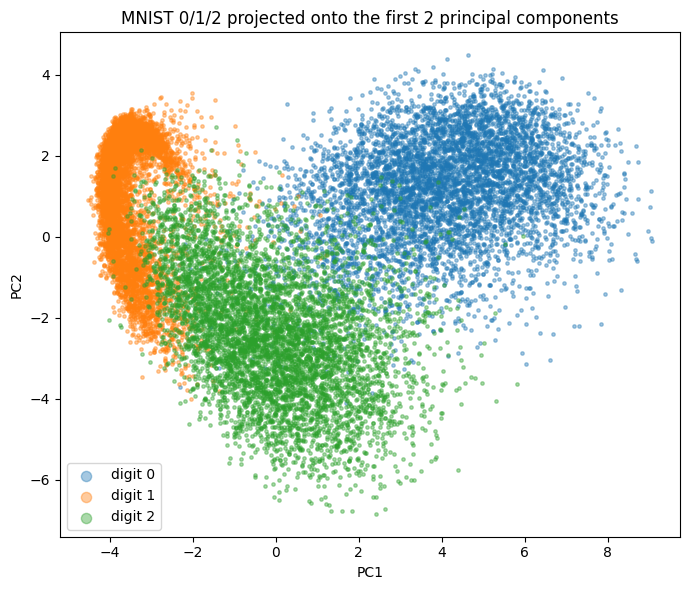

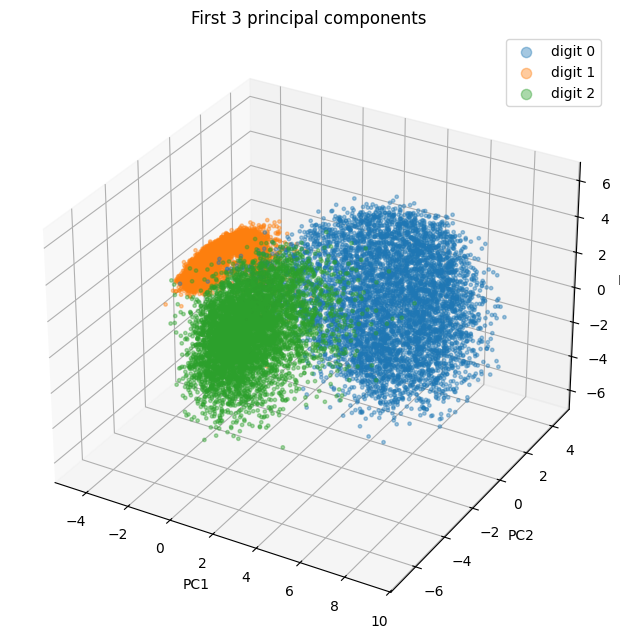

In [10]:
coords = project(pca, X)  # all components; plot_projection uses the leading ones
plot_projection(coords, y, [f"digit {d}" for d in DIGITS],
                suptitle="MNIST 0/1/2 projected onto the first 2 principal components")

## What PCA reveals about the three classes

- **Strong compressibility.** 68 of 784 components reach 90% variance (126 for 95%). The pixel space is heavily redundant — neighbouring pixels are correlated and the ink occupies a small, structured region — so PCA compresses it aggressively.
- **Unsupervised class structure.** Even in just 2 dimensions the digits form visibly distinct clouds *without ever using the labels*. **`1`** separates most cleanly (thin, near-vertical strokes give it an extreme, low-variance shape), while **`0`** and **`2`** overlap more because both fill a broad, rounded region of the canvas.
- **PC1/PC2 meaning.** The leading components track the dominant strokes-vs-background contrast and overall shape mass; the third component helps peel apart the 0/2 overlap.

This low-dimensional structure is what the sibling notebooks build on: reconstructing digits from a handful of components (compression) and sampling new ones (generation). **Part 2 below** runs the identical pipeline on Quick, Draw! sketches for contrast.

# Part 2 — Quick, Draw! sketches (cat / apple / car)

The **same pipeline** is applied to hand-drawn Quick, Draw! sketches.
`load_sketches` renders each vector drawing to the identical `(n, 784)`,
`[0, 1]`-scaled, 0 = background / 1 = ink contract, so every helper below is
reused verbatim — only the loader changes.

Each Quick, Draw! category holds over 100 000 drawings; the loader caps each at
`PER_CLASS = 10 000`, giving a balanced **30 000**-sketch matrix (10 000 `cat`,
10 000 `apple`, 10 000 `car`).

Sketches are messier than MNIST digits — freehand, wildly varied, and drawn in a
few seconds — so PCA is expected to need **more** components to reach the same
variance, and the classes to overlap more in 2D.

In [11]:
# Load the sketches (rendered arrays are cached under data/sketches/ after the first run).
X, y = load_sketches(per_class=PER_CLASS)
print(f"X {X.shape} {X.dtype} range [{X.min():.2f}, {X.max():.2f}]")
print(f"y {y.shape} classes {sorted(set(y.tolist()))} -> {CLASSES}")

# Same fit_pca, same helpers -- only the loader changed.
pca = fit_pca(X)
print(f"\nfitted PCA with {pca.n_components_} components")
print(f"top-5 explained-variance ratios: {np.round(pca.explained_variance_ratio_[:5], 4)}")

X (30000, 784) float32 range [0.00, 1.00]
y (30000,) classes [0, 1, 2] -> ['cat', 'apple', 'car']

fitted PCA with 784 components
top-5 explained-variance ratios: [0.0553 0.0333 0.0266 0.0223 0.0193]


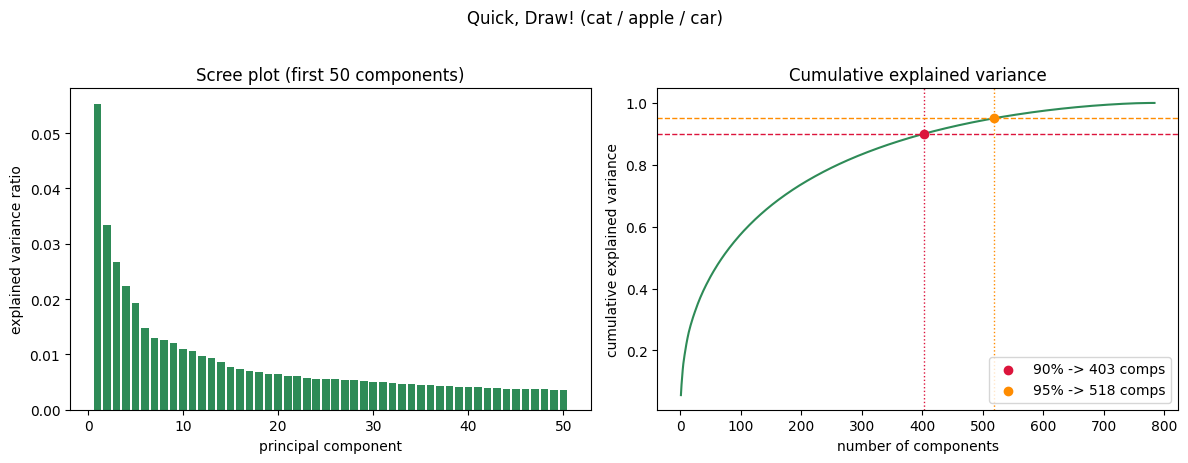

components for 90% variance: 403
components for 95% variance: 518


In [12]:
ks = plot_spectrum(pca, color="seagreen", suptitle="Quick, Draw! (cat / apple / car)")
print(f"components for 90% variance: {ks[0.90]}")
print(f"components for 95% variance: {ks[0.95]}")

### Per-feature vs. global centering, on sketches

The same two-means comparison as for MNIST, now on Quick, Draw!.

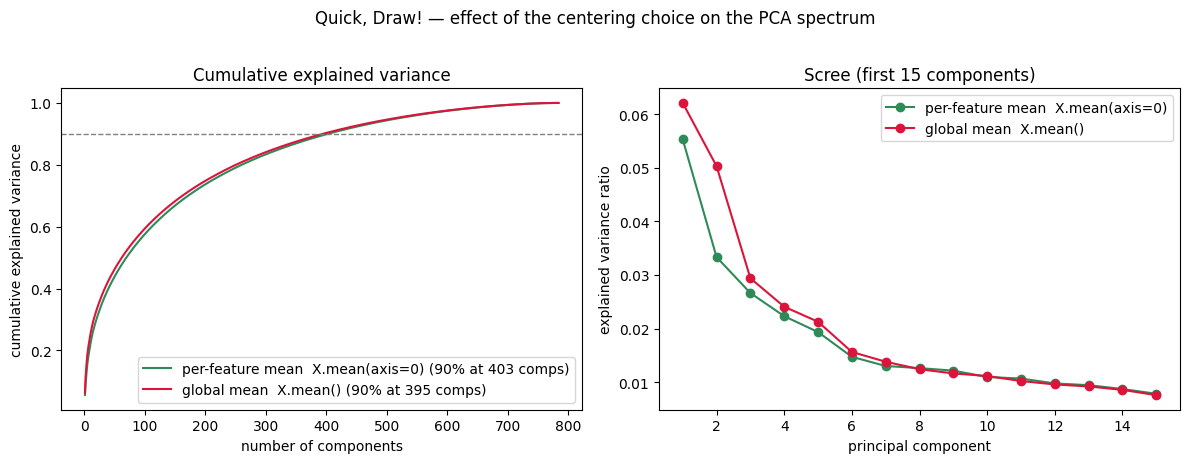

per-feature mean  X.mean(axis=0)    PC1 =   5.5% of variance   90% at 403 components
global mean  X.mean()               PC1 =   6.2% of variance   90% at 395 components


In [13]:
pca_feature = fit_pca(X, center="feature")  # per-feature mean, X.mean(axis=0)
pca_global = fit_pca(X, center="global")    # single global mean, X.mean()

summary = plot_spectrum_comparison(
    [pca_feature, pca_global],
    ["per-feature mean  X.mean(axis=0)", "global mean  X.mean()"],
    colors=["seagreen", "crimson"],
    suptitle="Quick, Draw! — effect of the centering choice on the PCA spectrum",
)
for label, pc1, k90 in summary:
    print(f"{label:34}  PC1 = {pc1:6.1%} of variance   90% at {k90} components")

On sketches the effect is **much weaker**: PC1 barely moves (≈5.5% → ≈6.2%) and
the two cumulative curves nearly coincide. Quick, Draw!'s mean image is faint and
diffuse — sketches are sparse and scattered across the canvas — so leaving it in
costs little. Where MNIST's bold mean image made global centering visibly distort
the spectrum, here it hardly registers. Per-feature centering is still the
principled choice; this simply shows *how much* it matters depends on how
structured the dataset's mean image is.

### Seeing the sketch components as images

The same three views on Quick, Draw!. Watch how much fainter the mean image is
than MNIST's — the visual reason global centering barely mattered above — and how
the eigen-sketches are broad, blobby patterns rather than crisp strokes.

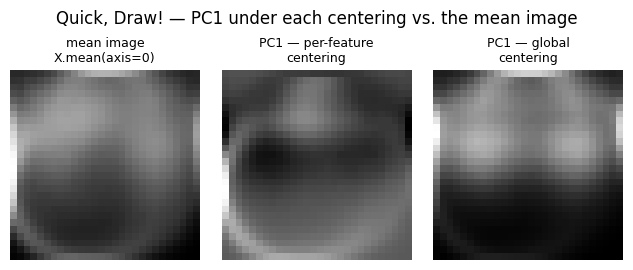

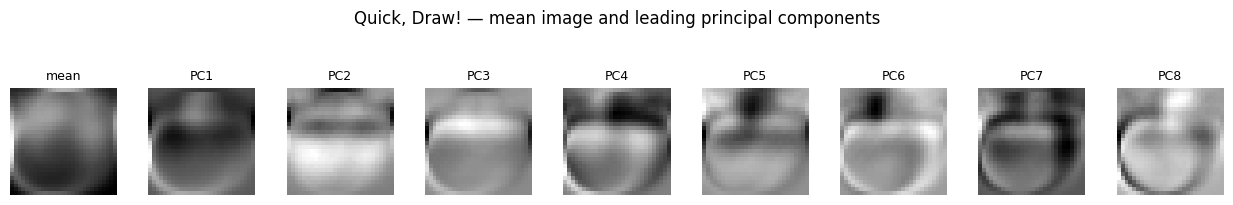

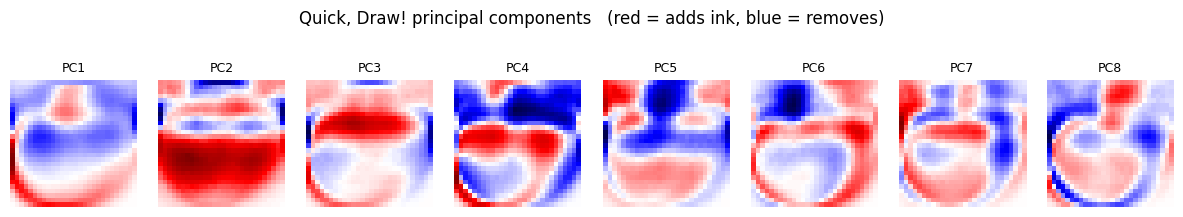

In [14]:
# PC1 under each centering vs. the mean sketch.
plot_pc1_vs_mean(X, suptitle="Quick, Draw! — PC1 under each centering vs. the mean image")

# Mean image + leading components as eigen-sketches, then as +/- heatmaps.
plot_eigenimages(pca, n=8, suptitle="Quick, Draw! — mean image and leading principal components")
plot_component_heatmaps(pca, n=8, suptitle="Quick, Draw! principal components")

Two things stand out against MNIST. The **mean image is pale and spread out** (no
single shared shape), so PC1-global barely resembles it and global centering cost
almost nothing. And the **eigen-sketches are diffuse blobs** with no crisp
strokes — the visual counterpart of needing 403 components for 90% variance:
there is no small set of sharp patterns that reconstructs a cat, an apple and a
car, the way a handful of stroke patterns reconstructs `0`/`1`/`2`.

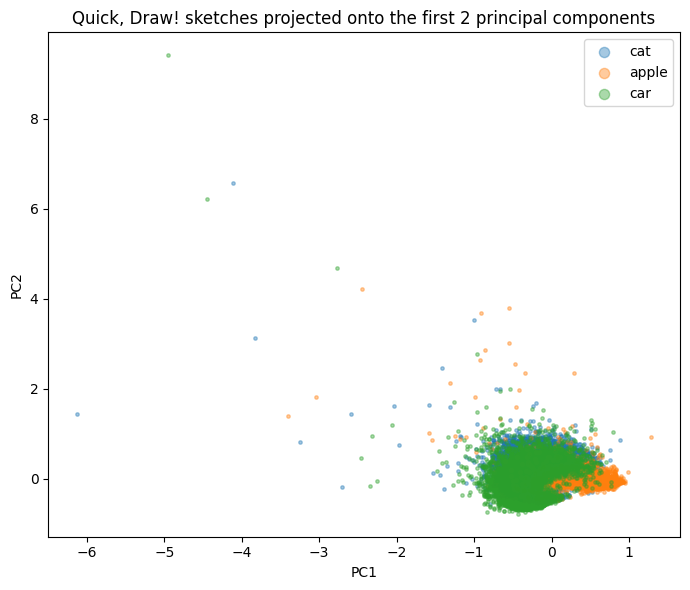

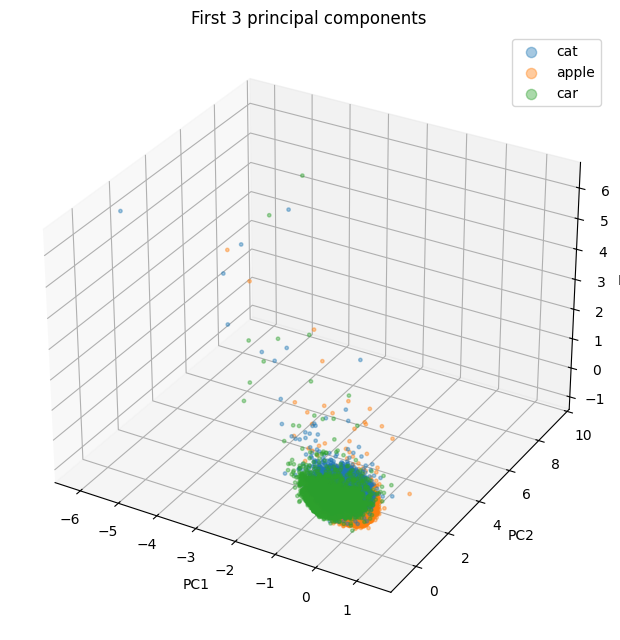

In [15]:
coords = project(pca, X)
plot_projection(coords, y, CLASSES,
                suptitle="Quick, Draw! sketches projected onto the first 2 principal components")

## MNIST vs. Quick, Draw! — what changed

Same pipeline, two very different datasets:

- **Far less compressible.** Reaching 90% / 95% variance took **403 / 518** components for the sketches, versus just **68 / 126** for MNIST — and PC1 alone explains only **~5.5%** of sketch variance against **~22%** for digits. Freehand drawings vary far more than centred, size-normalised digits, so their pixel variance is spread across many more directions: the scree curve is much flatter and the cumulative curve climbs slowly.
- **Weaker unsupervised separation.** In the PC1/PC2 scatter the three sketch classes overlap heavily, where MNIST's `0/1/2` formed cleaner clouds. `cat`, `apple` and `car` share a similar overall ink footprint (a blob of strokes centred on the canvas), so the leading, variance-based axes don't split them as cleanly as the strongly-shaped digits.
- **Same machinery, no code change.** Because both datasets honour the identical `(n, 784)`, `[0, 1]` contract, the from-scratch PCA and every helper ran verbatim on each — only the loader differed.